# Oriented Bounding Boxes (OBB) Demo: „Boxen mit Rotation“

Normale Objekterkennung nutzt rechteckige Bounding Boxes. Diese Bounding Boxes sind 
immer **parallel** zu den Bildrändern! Bei vielen Anwendungen liegen Objekte aber
schräg, z.B. in Satellitenaufnahmen.

**OBB (Oriented Bounding Box)** bedeutet:
- Die Box kann **gedreht** sein
- Dadurch passt sie enger um das Objekt
- Neben Klasse + Konfidenz bekommen wir zusätzliche Geometrie-Infos (Rotation / Eckpunkte)

Wir gehen wieder Schritt für Schritt vor:
1) Bild laden und anschauen
2) OBB-Modell laden
3) Inferenz ausführen
4) Result untersuchen:
   - wie viele Objekte wurden gefunden?
   - welche Klassen + Konfidenzen?
   - wie sind die OBB-Koordinaten repräsentiert?
5) Visualisierung der OBBs

## Für Colab...

In [ ]:
# relevante Pakete (einmal mehr..)
!pip -q install ultralytics opencv-python matplotlib numpy

# drive mounten, damit wir auf die Bilder/Videos zugreifen können
from google.colab import drive
drive.mount('/content/drive')

img_bgr is None? False


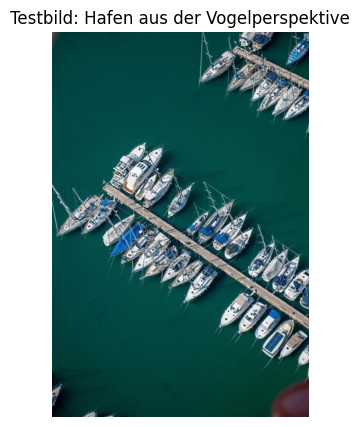

In [ ]:
import cv2
import matplotlib.pyplot as plt

# für Colab: 
# img_path = "/content/drive/MyDrive/DIH-CV-main/images/birdeye/harbour.png"
img_path = "/home/u88m52/projects/DIH-CV/images/birdeye/harbour.png"
img_bgr = cv2.imread(img_path)
print("img_bgr is None?", img_bgr is None)

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Testbild: Hafen aus der Vogelperspektive")
plt.show()

## OBB-Modell laden...

Wir haben das Bild geladen und angeschaut; als nächstes laden wir ein YOLO-OBB-Modell.
Das unterscheidet sich von normaler Detection dadurch, dass die Boxen nicht achsenparallel sind,
sondern eine Rotation enthalten. Sehen wir uns das an:

In [6]:
from ultralytics import YOLO

obb_model = YOLO("yolo11s-obb.pt")
obb_model

result = obb_model.predict(img_path, conf=0.25, iou=0.45, verbose=False)
r0 = result[0]
print(r0)

ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'plane', 1: 'ship', 2: 'storage tank', 3: 'baseball diamond', 4: 'tennis court', 5: 'basketball court', 6: 'ground track field', 7: 'harbor', 8: 'bridge', 9: 'large vehicle', 10: 'small vehicle', 11: 'helicopter', 12: 'roundabout', 13: 'soccer ball field', 14: 'swimming pool'}
obb: ultralytics.engine.results.OBB object
orig_img: array([[[ 97,  96,  98],
        [ 91,  90,  92],
        [ 82,  81,  83],
        ...,
        [ 45,  45,   4],
        [ 37,  39,   0],
        [ 45,  50,  10]],

       [[ 94,  93,  96],
        [ 86,  85,  88],
        [ 78,  77,  80],
        ...,
        [ 40,  36,   0],
        [ 99,  99,  60],
        [106, 106,  67]],

       [[ 90,  90,  90],
        [ 82,  81,  82],
        [ 73,  73,  73],
        ...,
        [124, 113,  85],
        [153, 145, 110],
        [ 81,  73,  36]],

       ...,

       [[ 13,   8,   2],
        [ 15,  11,   5],


Das ist interessant: wir haben hier weder `boxes`, noch `keypoints` oder `masks`. 
Stattdessen haben wir aber ein anderes Attribut: `obb`. Sehen wir uns das genauer an:

In [10]:
# Klassen + Konfidenzen
cls_ids = r0.obb.cls.cpu().numpy().astype(int)
confs = r0.obb.conf.cpu().numpy()

print("cls shape:", r0.obb.cls.shape)
print("conf shape:", r0.obb.conf.shape)

# OBB-Geometrie: zuerst versuchen wir xywhr (center x/y, w, h, rotation)
has_xywhr = hasattr(r0.obb, "xywhr") and r0.obb.xywhr is not None
print("Hat obb.xywhr?", has_xywhr)

if has_xywhr:
    xywhr = r0.obb.xywhr.cpu().numpy()
    print("xywhr shape:", xywhr.shape)
    print("Erste Zeile (cx, cy, w, h, r):", xywhr[0] if len(xywhr) else None)
else:
    print("Kein xywhr gefunden – wir prüfen gleich auf Eckpunkte/Polygone.")

cls shape: torch.Size([41])
conf shape: torch.Size([41])
Hat obb.xywhr? True
xywhr shape: (41, 5)
Erste Zeile (cx, cy, w, h, r): [     353.25      474.88       23.82      68.577     0.67947]


Wir haben Klassen-IDs und Konfidenzen, und (wenn verfügbar) auch `xywhr`.

Als nächstes geben wir die ersten paar Detektionen lesbar aus:
- Klassenname
- Konfidenz
- und (falls vorhanden) OBB-Parameter

So sieht man sehr gut: bei OBB kommt zusätzlich zur Klasse eine „Rotation/Orientierung“ dazu.

In [ ]:
n_show = min(10, len(r0.obb))

for j in range(n_show):
    cls_id = int(cls_ids[j])
    name = r0.names[cls_id]
    conf = float(confs[j])

    if has_xywhr:
        cx, cy, w, h, rot = xywhr[j]
        print(f"{j:02d} | {name:<18} conf={conf:.3f} | (cx,cy,w,h,rot)=({cx:.1f},{cy:.1f},{w:.1f},{h:.1f},{rot:.3f})")
    else:
        print(f"{j:02d} | {name:<18} conf={conf:.3f}")

00 | ship               conf=0.875 | (cx,cy,w,h,rot)=(353.2,474.9,23.8,68.6,0.679)
01 | ship               conf=0.864 | (cx,cy,w,h,rot)=(334.4,457.5,20.8,53.1,0.686)
02 | ship               conf=0.862 | (cx,cy,w,h,rot)=(309.3,446.1,21.8,60.4,0.689)
03 | ship               conf=0.862 | (cx,cy,w,h,rot)=(142.1,214.1,26.0,91.1,0.705)
04 | ship               conf=0.858 | (cx,cy,w,h,rot)=(326.2,354.7,20.4,63.8,0.600)
05 | ship               conf=0.858 | (cx,cy,w,h,rot)=(283.5,433.9,23.2,69.9,0.729)
06 | ship               conf=0.856 | (cx,cy,w,h,rot)=(366.0,376.3,21.9,67.3,0.607)
07 | ship               conf=0.855 | (cx,cy,w,h,rot)=(373.2,488.0,18.7,55.9,0.728)
08 | ship               conf=0.855 | (cx,cy,w,h,rot)=(167.5,361.5,19.3,72.7,0.849)
09 | ship               conf=0.855 | (cx,cy,w,h,rot)=(346.9,364.1,19.6,63.2,0.634)


## Visualisierung der Ergebnisse

Die ersten zehn Objekte wurden alle als Schiffe identifiziert. Schauen wir uns nun direkt
am Bild an, ob die Detektionen (und die dazugehörigen OBBs!) tatsächlich stimmen.

Dank YOLO Outputstruktur geht das wieder gewohnt leicht:

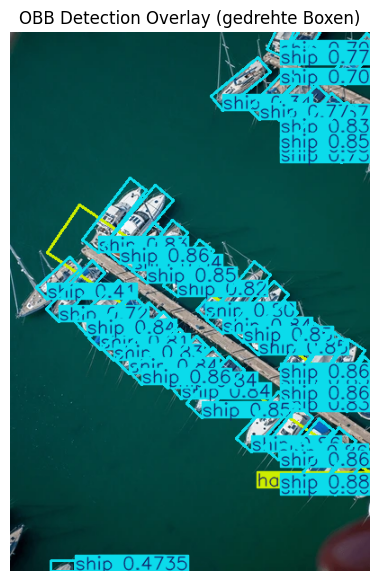

Erkannte Klassen: ['harbor', 'ship']


In [15]:
annotated_bgr = r0.plot()
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("OBB Detection Overlay (gedrehte Boxen)")
plt.show()

class_names = [r0.names[cls_id] for cls_id in cls_ids]
print("Erkannte Klassen:", list(set(class_names)))

Wir sehen jetzt die gedrehten Boxen im Bild – das ist der Hauptvorteil von OBB:
Bei schrägen Objekten passt die Box deutlich besser als eine achsenparallele Box.

Als nächstes (optional) machen wir eine kleine Übung:
Wir zählen, wie viele Objekte insgesamt erkannt wurden und wie viele pro Klasse.
Das ist die gleiche Auswertung wie bei Detection – nur mit OBB-Boxen.

In [16]:
from collections import Counter

detected_names = [r0.names[int(i)] for i in cls_ids]
counts = Counter(detected_names)

print("Anzahl Detektionen:", len(detected_names))
print("Klassenhäufigkeiten:")
counts

Anzahl Detektionen: 41
Klassenhäufigkeiten:


Counter({'ship': 40, 'harbor': 1})

## Zusammenfassend...

Damit ist die OBB-Demo komplett. Wir haben nun gesehen:

- OBB liefert (wie Detection) Klasse + Konfidenz pro Objekt
- zusätzlich eine „rotierte“ Box-Geometrie (z.B. als xywhr oder Eckpunkte)
- Visualisierung zeigt den Nutzen bei schrägen Objekten sehr deutlich

Wir sind jetzt mit den Standardkompetenzen von CV-Modellen durch - als nächstes sehen
wir uns noch an, wie sich das alles ändert, sobald man von einzelnen Frames auf Videos
wechselt.